
# Exercise: CNN Classification - CIFAR-10 dataset
## 1. Import Libraries


In [1]:
# 1. Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  2


## 2. Load and Inspect the Dataset

In [2]:
# 2. Load and preprocess the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(X_train.shape, X_test.shape)


(50000, 32, 32, 3) (10000, 32, 32, 3)


### Class Names

In [3]:

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

## 3. Visualize Sample Images

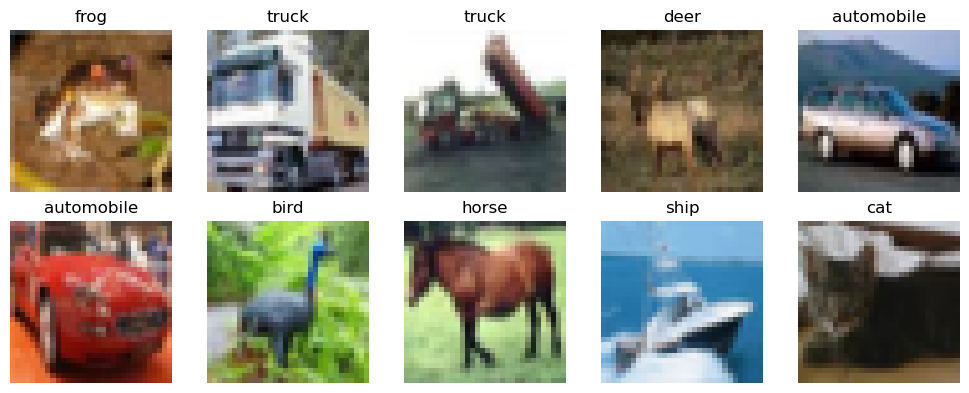

In [4]:
# 3. Visualize some sample images from the dataset
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Build a CNN Model

In [5]:
# 4. Build a simple CNN model
img_size = (32, 32)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='valid', input_shape=(img_size[0],img_size[1],3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='valid'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='valid'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 2, 2, 64)          0

2026-04-20 08:07:02.608830: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 08:07:02.610092: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 08:07:02.611309: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## 5. Train the Model

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

# T9.b) Introducing early stopping finding minimum val_loss
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',               
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30


2026-04-20 08:07:04.192846: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8800
2026-04-20 08:07:04.915372: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f1af36b9170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-20 08:07:04.915401: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-04-20 08:07:04.915406: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-04-20 08:07:04.918676: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776665224.979884 2236090 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 [==============================] - 4s 4ms/step - loss: 1.7828 - accuracy: 0.3357 - val_loss: 1.4691 - val_accuracy: 0.4586
Epoch 2/30
625/625 [==============================] - 2s 3ms/step - loss: 1.4067 - accuracy: 0.4918 - val_loss: 1.2608 - val_accuracy: 0.5502
Epoch 3/30
625/625 [==============================] - 2s 2ms/step - loss: 1.2713 - accuracy: 0.5470 - val_loss: 1.1731 - val_accuracy: 0.5818
Epoch 4/30
625/625 [==============================] - 2s 3ms/step - loss: 1.1793 - accuracy: 0.5817 - val_loss: 1.0985 - val_accuracy: 0.6066
Epoch 5/30
625/625 [==============================] - 2s 3ms/step - loss: 1.1037 - accuracy: 0.6101 - val_loss: 1.0235 - val_accuracy: 0.6418
Epoch 6/30
625/625 [==============================] - 2s 3ms/step - loss: 1.0409 - accuracy: 0.6338 - val_loss: 1.0449 - val_accuracy: 0.6329
Epoch 7/30
625/625 [==============================] - 2s 3ms/step - loss: 0.9959 - accuracy: 0.6513 - val_loss: 0.9851 - val_accuracy: 0.6477
Epoch 8/30
625/62

## 6. Evaluate the Model on test dataset

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

y_true = y_test.flatten()

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 [==============================] - 0s 1ms/step - loss: 0.8794 - accuracy: 0.6963
Test accuracy: 0.6963000297546387
313/313 [==============================] - 0s 721us/step


## 7. Precision, Recall, F1-score

In [8]:

print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1:", f1_score(y_true, y_pred, average='weighted'))


Precision: 0.6948660987920396
Recall: 0.6963
F1: 0.692874379980511


## 8. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[736  21  36  14  32   2   9  11 106  33]
 [ 20 836   1   5   4   3   7   2  48  74]
 [ 79  10 480  72 110  72 102  44  19  12]
 [ 16  16  52 546  68 134  88  37  21  22]
 [ 19   8  44  76 669  11  71  81  14   7]
 [ 12   9  41 225  55 529  38  57  15  19]
 [  4   7  40  67  42   7 802  12   7  12]
 [ 21   5  25  51  63  55  16 734   6  24]
 [ 67  28   5  12   4   3   5   3 843  30]
 [ 36  99   3  12   5   6   5  12  34 788]]


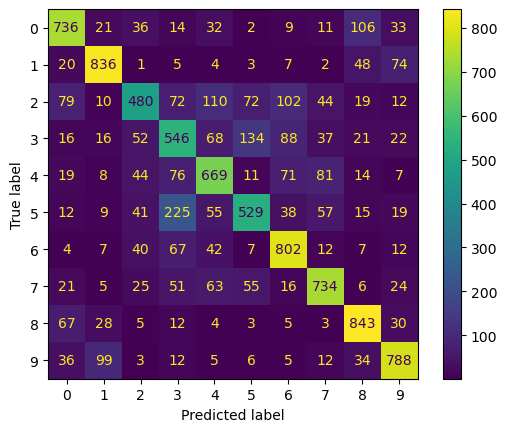

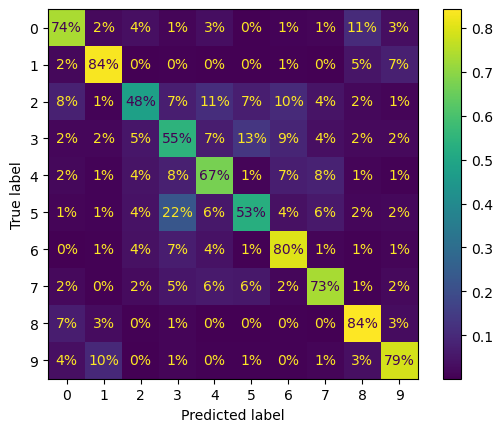

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize="true", values_format=".0%")
plt.show()


## 9. Residual Units

- Q9.a) Does ResidualBlocks improve convergence?\
Yes, that is the point of the skip connection. During backpropergation, the gradient can drecrease to a very small number, meaning that the weights in the early layers wont matter, this would create convergens problems, residual blocks allow the gradient to move past the minimizing weights in the last layers.

- Q9.b) Does ResidualBlocks reduce overfitting?\
No, but this can be done by other methods such as Dropout and batch normalization.

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


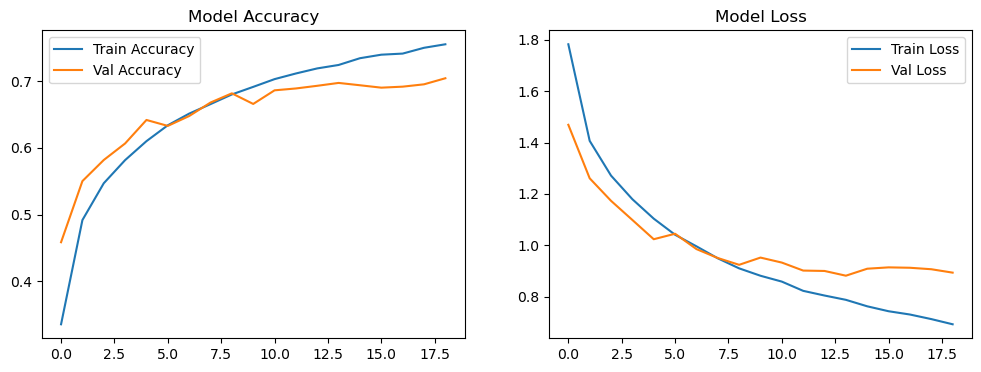

In [11]:
# T9.a) Plot training history and accuracy curves
import matplotlib.pyplot as plt

print(history.history.keys())

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

### Residual Unit Implementation

In [12]:
from functools import partial
import tensorflow as tf

DefaultConv2D = partial(tf.keras.layers.Conv2D,
                        kernel_size=3,
                        strides=1,
                        padding='same',
                        kernel_initializer='he_normal',
                        use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        z = inputs
        for layer in self.main_layers:
            z = layer(z)
        skip_z = inputs
        for layer in self.skip_layers:
            skip_z = layer(skip_z)
        return self.activation(z + skip_z)

### Residual units used in a Modified ResNet-34 Model

In [13]:
model = tf.keras.Sequential([
    DefaultConv2D(64, kernel_size=3, strides=1, input_shape=[32, 32, 3]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding='same'),
])

# lighter ResNet
prev_filters = 64
for filters in [64]*2 + [128]*2 + [256]*2:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

model.add(tf.keras.layers.GlobalAveragePooling2D())
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

# optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 32, 32, 64)        1728      
                                                                 
 batch_normalization (Batch  (None, 32, 32, 64)        256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 32, 32, 64)        0         
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                                 
 residual_unit (ResidualUni  (None, 16, 16, 64)        74240     
 t)                                                              
                                                      

Epoch 1/50
625/625 [==============================] - 15s 15ms/step - loss: 1.4156 - accuracy: 0.5092 - val_loss: 2.2183 - val_accuracy: 0.3810
Epoch 2/50
625/625 [==============================] - 8s 12ms/step - loss: 0.8952 - accuracy: 0.6892 - val_loss: 1.4616 - val_accuracy: 0.5456
Epoch 3/50
625/625 [==============================] - 8s 12ms/step - loss: 0.6998 - accuracy: 0.7606 - val_loss: 0.8446 - val_accuracy: 0.7212
Epoch 4/50
625/625 [==============================] - 8s 12ms/step - loss: 0.5724 - accuracy: 0.8034 - val_loss: 0.6576 - val_accuracy: 0.7693
Epoch 5/50
625/625 [==============================] - 8s 12ms/step - loss: 0.4682 - accuracy: 0.8407 - val_loss: 0.8430 - val_accuracy: 0.7356
Epoch 6/50
625/625 [==============================] - 8s 12ms/step - loss: 0.3757 - accuracy: 0.8701 - val_loss: 0.7594 - val_accuracy: 0.7572
Epoch 7/50
625/625 [==============================] - 8s 12ms/step - loss: 0.2954 - accuracy: 0.8982 - val_loss: 0.8861 - val_accuracy: 0.745

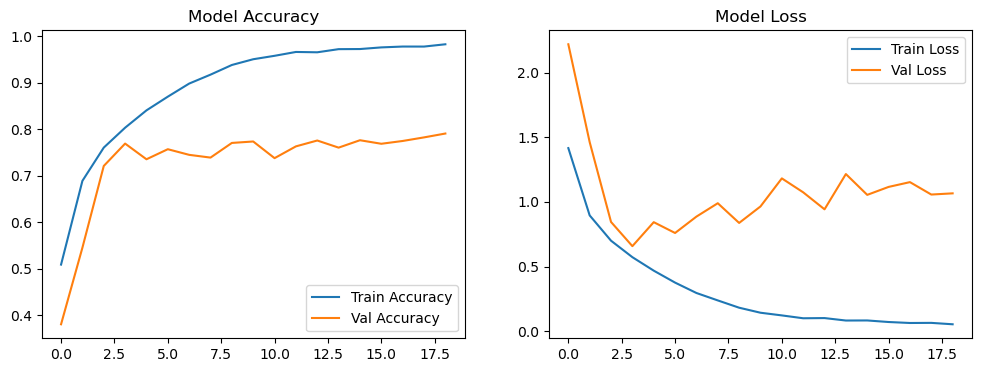

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# trying residual block with GPU cluster
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',               
    restore_best_weights=True
)

history2 = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

y_true = y_test.flatten()

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1:", f1_score(y_true, y_pred, average='weighted'))

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()


## 10. Questions for reflection

- Q10.a) Show how to find and calculated the 18496 parameters used in the second Conv layer? (Base model without residual units)\
Assuming Padding=same, for easier explaination of the output dimensions. The first convolution has 32 filters which makes the output $x \cdot x \cdot 32$, then a maxpooling reduces the size to $x/2 \cdot x/2 \cdot 32$, then convolution 2 has 64 filters each with a filter of 3x3, this must be done on each of the 32 filters from conv1, making the number of weights needed for this convolution: $(32 \cdot 3 \cdot 3 \cdot 64) =18432$.
The parameters explains the number of training variables. For each filter the the bias term is added making the total parameters: $(32 \cdot 3 \cdot 3 \cdot 64) + 64 =18496$
  
- Q10.b) What happens if padding='same' is changed to 'valid' and what does it means?\
When changing the padding to valid, less information is kept in the corners, here the convolution is only the 3x3 pixels from the photo, when the padding is set to 'same' the input is the same as the output in this case there will be added a zero boundary pixel all the way around, this ensures that more infomation i kept in the convolution. Using padding='same' makes the accuracy a 5% better, but bear in mind that this is only a 32x32 pixel photo, for higher resolution photos the object of interest is most often not in the corners, meaning that the accuracy will most likely be better but not much. Using padding='valid' is computationally lighter, since the pixel of interest is reduced by 2 in the vertical and horizontal dimensions 32x32 -> 30x30.

- Q10.c) Does the residual units improve model accuracy?\
Yes the accuracy is increased by 5%, but i experienced that the validation accuracy and loss fluctuated a lot, this was reduced by using stide=1, and using a lighter resnet version where the convolution with the most filters is 2*265, and the input=[32, 32, 3] to fit the input data from cifar10.
